In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [4]:
customer_id= df['customerID']
df.drop('customerID', axis=1, inplace=True)

In [5]:
#Assuming that if we loose a customer, we lose the revenue from that customer for an entire year in average. Assuming that to be their remaining linetime.
#Calculating revenue lost from False Negative detected customers = 12 Months * MonthlyCharge

df['FN_cost'] = df['MonthlyCharges'] * 12
print(df['FN_cost'].describe())

#Assuming that upon False Positive detected customers, we offer them an average of 50$ in incentives to retain them.
df['FP_cost'] = 50


count    7032.000000
mean      777.578498
std       361.031687
min       219.000000
25%       427.050000
50%       844.200000
75%      1078.350000
max      1425.000000
Name: FN_cost, dtype: float64


In [6]:
df['MonthlyCharges'].describe()


count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

In [7]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='str').columns.tolist()
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [8]:
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_enc.shape


(7032, 33)

In [9]:
X = df_enc.drop(['Churn', 'FN_cost', 'FP_cost'], axis=1)
y= df_enc['Churn']
fn_cos = df_enc['FN_cost']
fp_cos = df_enc['FP_cost']


In [10]:
X_train, X_temp, y_train, y_temp, fn_train, fn_temp, fp_train, fp_temp = train_test_split(X, y, fn_cos, fp_cos, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test, fn_val, fn_test, fp_val, fp_test = train_test_split(X_temp, y_temp, fn_temp, fp_temp, test_size=0.5, stratify=y_temp, random_state=42)


In [12]:
import json
with open('feature_names.json', 'w') as f:
    json.dump(list(X_train.columns), f)

In [13]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (4219, 30), Val: (1406, 30), Test: (1407, 30)


In [14]:
from xgboost import XGBClassifier 

base = XGBClassifier(random_state=42,
                     eval_metric = 'aucpr',
                     n_estimators=300,
                     early_stopping_rounds=20
                     )
base.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
base_probs_val = base.predict_proba(X_val)[:, 1]
base_probs_test = base.predict_proba(X_test)[:, 1]

In [15]:
#Creating a cost function to calculate the expected real life cost of a given threshold.
def exp_cost(y_true, probs, fn_costs, fp_costs, threshold):
    y_pred = (probs >= threshold).astype(int)
    fn_cost = np.sum(fn_costs[(y_true == 1) & (y_pred == 0)])
    fp_cost = np.sum(fp_costs[(y_true == 0) & (y_pred == 1)])
    return fn_cost + fp_cost

In [16]:
thresholds = np.arange(0.01, 1.0, 0.01 )
val_costs = [exp_cost(y_val, base_probs_val, fn_val, fp_val, t) for t in thresholds]
best_thres = thresholds[np.argmin(val_costs)]
best_val_cost = np.min(val_costs)

print(f"Optimal threshold: {best_thres:.2f}")
print(f"Expected cost at optimal threshold: ${best_val_cost:,.2f}")

Optimal threshold: 0.04
Expected cost at optimal threshold: $37,609.40


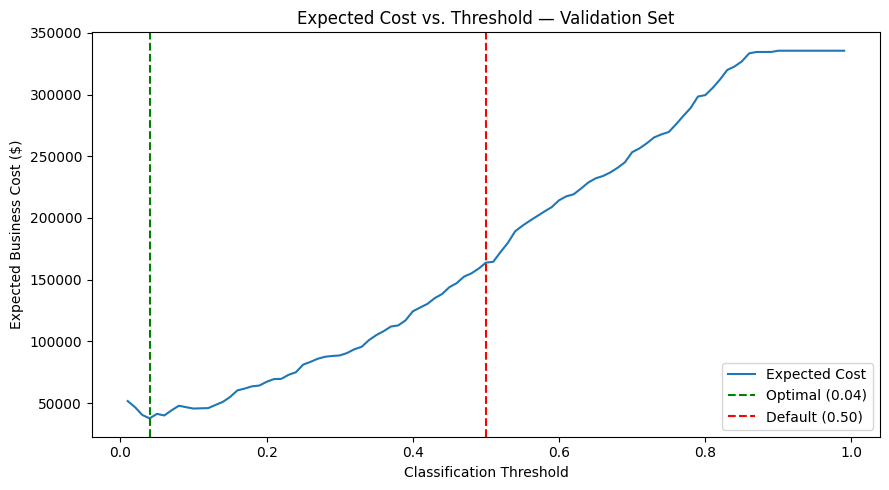

In [17]:

plt.figure(figsize=(9, 5))
plt.plot(thresholds, val_costs, label='Expected Cost')
plt.axvline(best_thres, color='green', linestyle='--', label=f'Optimal ({best_thres:.2f})')
plt.axvline(0.5, color='red', linestyle='--', label='Default (0.50)')
plt.xlabel('Classification Threshold')
plt.ylabel('Expected Business Cost ($)')
plt.title('Expected Cost vs. Threshold — Validation Set')
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
default_test_cost = exp_cost(y_test, base_probs_test, fn_test, fp_test, 0.5)
optimal_test_cost = exp_cost(y_test, base_probs_test, fn_test, fp_test, best_thres)

savings = default_test_cost - optimal_test_cost
print(f"Test set — Default (0.50) cost:  ${default_test_cost:,.2f}")
print(f"Test set — Optimal ({best_thres:.2f}) cost: ${optimal_test_cost:,.2f}")
print(f"Savings: ${savings:,.2f} ({(savings / optimal_test_cost) * 100:.1f}%)")

Test set — Default (0.50) cost:  $152,623.80
Test set — Optimal (0.04) cost: $39,557.40
Savings: $113,066.40 (285.8%)


In [19]:
#Training a weighted model
sample_weights = np.where(y_train ==1, fn_train, fp_train)

weighted_model = XGBClassifier(random_state=42,
                     eval_metric = 'aucpr',
                     n_estimators=300,
                     early_stopping_rounds=20
                     )

weighted_model.fit(X_train, y_train, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=False)

weighted_probs_val = weighted_model.predict_proba(X_val)[:, 1]
weighted_probs_test = weighted_model.predict_proba(X_test)[:, 1]

In [20]:
weighted_val_costs = [exp_cost(y_val, weighted_probs_val, fn_val, fp_val, t) for t in thresholds]

weighted_best_thres = thresholds[np.argmin(weighted_val_costs)]
weighted_test_cost = exp_cost(y_test, weighted_probs_test, fn_test, fp_test, weighted_best_thres)

print(f"Weighted model — optimal threshold: {weighted_best_thres:.2f}")
print(f"Weighted model — test cost: ${weighted_test_cost:,.2f}")

Weighted model — optimal threshold: 0.18
Weighted model — test cost: $40,492.80


In [21]:
def summarize(name, y_true, probs, threshold, fn_cost_arr, fp_cost_arr):
    preds = (probs >= threshold).astype(int)
    return {
        'Model': name,
        'Threshold': round(threshold, 2),
        'Accuracy': round(accuracy_score(y_true, preds), 4),
        'F1': round(f1_score(y_true, preds), 4),
        'AUC': round(roc_auc_score(y_true, probs), 4),
        'Expected Cost ($)': round(exp_cost(y_true, probs, fn_cost_arr, fp_cost_arr, threshold), 2)
    }

In [22]:
results = []
results.append(summarize('Baseline @ 0.50 (default)', y_test, base_probs_test, 0.50, fn_test, fp_test))
results.append(summarize('Baseline @ optimal threshold', y_test, base_probs_test, best_thres, fn_test, fp_test))
results.append(summarize('Cost-weighted @ optimal threshold', y_test, weighted_probs_test, weighted_best_thres, fn_test, fp_test))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                            Model  Threshold  Accuracy     F1    AUC  Expected Cost ($)
        Baseline @ 0.50 (default)       0.50    0.7996 0.5753 0.8444           152623.8
     Baseline @ optimal threshold       0.04    0.4662 0.4963 0.8444            39557.4
Cost-weighted @ optimal threshold       0.18    0.5124 0.5142 0.8025            40492.8


In [23]:
flagged_pct = (base_probs_test >= 0.04).mean()
print(f"{flagged_pct*100:.1f}% of test customers flagged at threshold 0.04")

79.4% of test customers flagged at threshold 0.04


In [24]:
def exp_cost_with_capacity(y_true, probs, threshold, fn_cost_arr, fp_cost_arr, max_flag_pct=None):
    preds = (probs >= threshold).astype(int)
    flagged_pct = preds.mean()
    if max_flag_pct is not None and flagged_pct > max_flag_pct:
        return np.inf, flagged_pct  
    y_true_arr = np.array(y_true)
    fn_mask = (preds == 0) & (y_true_arr == 1)
    fp_mask = (preds == 1) & (y_true_arr == 0)
    cost = fn_cost_arr[fn_mask].sum() + fp_cost_arr[fp_mask].sum()
    return cost, flagged_pct

In [25]:
capacity_levels = [0.10, 0.20, 0.30, 0.50, 1.0]

In [26]:
capacity_results = []
for cap in capacity_levels:
    costs_at_cap = []
    for t in thresholds:
        cost, flagged = exp_cost_with_capacity(y_val, base_probs_val, t, fn_val, fp_val, max_flag_pct=cap)
        costs_at_cap.append(cost)
    best_idx = np.argmin(costs_at_cap)
    best_t = thresholds[best_idx]
    best_cost_val = costs_at_cap[best_idx]
    
    # Evaluate that threshold on test set (honest, no leakage)
    test_cost, test_flagged_pct = exp_cost_with_capacity(y_test, base_probs_test, best_t, fn_test, fp_test, max_flag_pct=1.0)
    capacity_results.append({
        'Capacity Cap': f'{int(cap*100)}%' if cap < 1.0 else 'Unconstrained',
        'Best Threshold': round(best_t, 2),
        'Test Cost ($)': round(test_cost, 2),
        'Actual % Flagged (test)': round(test_flagged_pct * 100, 1)
    })

capacity_df = pd.DataFrame(capacity_results)
print(capacity_df.to_string(index=False))

 Capacity Cap  Best Threshold  Test Cost ($)  Actual % Flagged (test)
          10%            0.68       225526.8                     10.1
          20%            0.50       152623.8                     20.6
          30%            0.39        94887.4                     32.0
          50%            0.20        47595.8                     49.9
Unconstrained            0.04        39557.4                     79.4


In [27]:
# taking the 30% capacity cap threshold (0.39) as the best threshold for the model, 
# assuming the company can cater to only 30% of the customers flagged for retention incentives. 
# This threshold is chosen based on the balance between minimizing costs and the company's capacity to handle flagged customers.

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5, 1],
}

In [29]:
search = RandomizedSearchCV(
    XGBClassifier(eval_metric='aucpr', random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``ref

In [30]:
print("Best params:", search.best_params_)
best_model = search.best_estimator_

Best params: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}


In [31]:
best_thres = 0.39

test_probs = best_model.predict_proba(X_test)[:, 1]
cost_default = exp_cost(y_test, test_probs, fn_test, fp_test, 0.5)
cost_optimal = exp_cost(y_test, test_probs, fn_test, fp_test, best_thres)
savings = cost_default - cost_optimal

print(f"Test AUC: {roc_auc_score(y_test, test_probs):.4f}")
print(f"Cost at default (0.5): ${cost_default}")
print(f"Cost at optimal ({best_thres:.2f}): ${cost_optimal}")
print(f"Savings: ${savings} ({savings/cost_default*100:.1f}%)")


Test AUC: 0.8349
Cost at default (0.5): $38404.4
Cost at optimal (0.39): $34667.0
Savings: $3737.4000000000015 (9.7%)


In [32]:
best_model.save_model('churn_model_final.json')

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

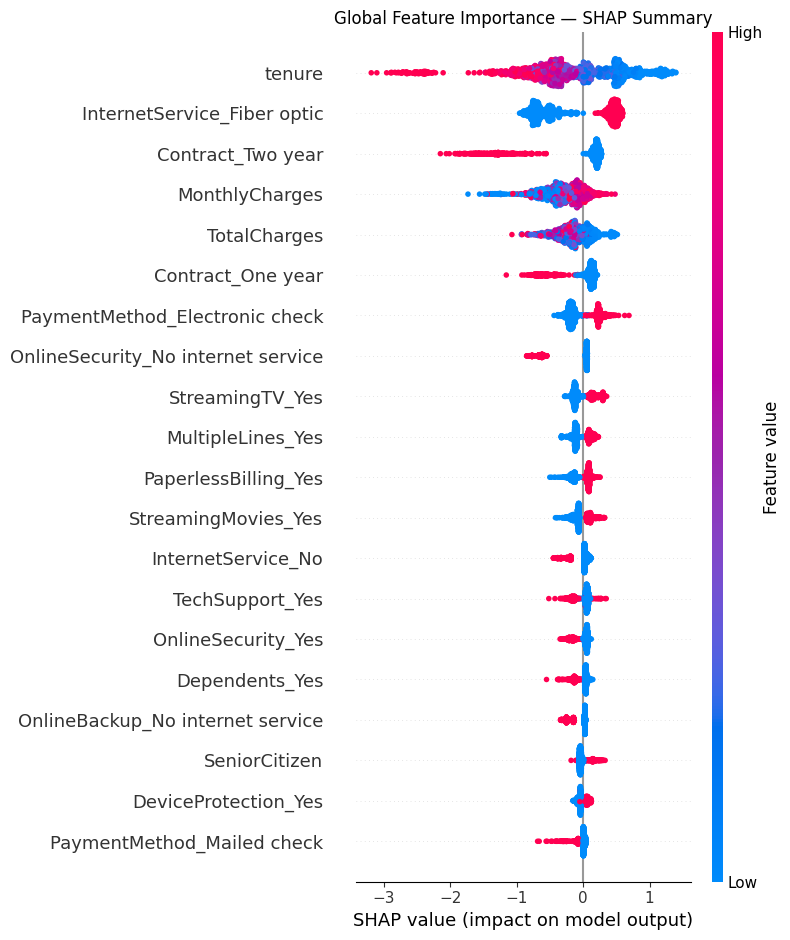

In [ ]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Global Feature Importance — SHAP Summary")
plt.tight_layout()
plt.show()

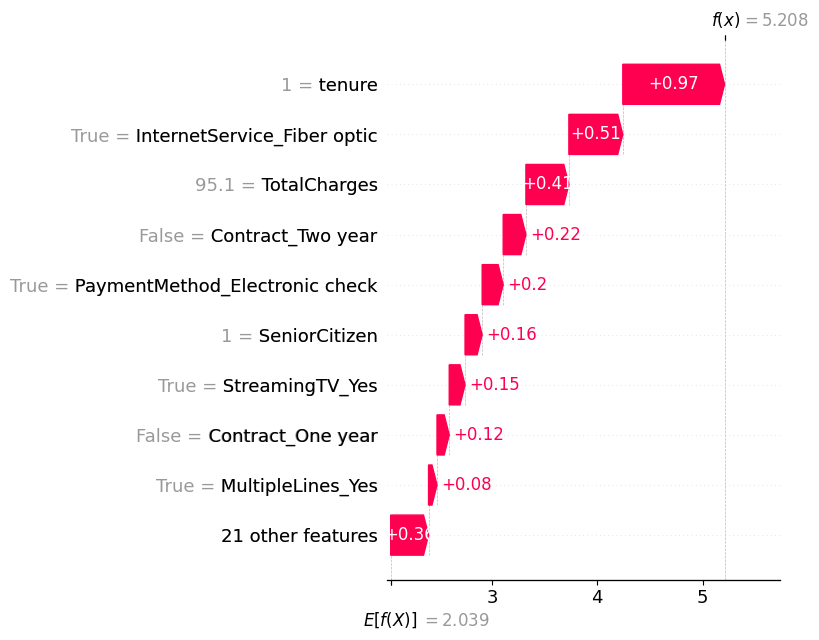

Customer predicted churn probability: 99.46%


In [ ]:
high_risk_idx = np.argmax(test_probs)

# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.show()

print(f"Customer predicted churn probability: {test_probs[high_risk_idx]:.2%}")

In [ ]:
import json

model_config = {
    'optimal_threshold': best_thres,          
    'fn_cost_formula': 'monthly_charges * 12',  
    'fn_cost_multiplier': 12,                  
    'fp_cost': 50,                             
    'capacity_cap': 0.30,                       
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)